# Lab 9 — SVM classification and PCA dimensionality reduction

Part A trains a Support Vector Machine on the Breast Cancer Wisconsin dataset and tunes its hyperparameters. Part B applies PCA to the Wine dataset, checks how much variance the components keep, and compares the result against LDA. Both datasets are pulled live from the UCI repository via `ucimlrepo`.

In [1]:
try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    %pip install -q ucimlrepo
    from ucimlrepo import fetch_ucirepo

## Part A — Support Vector Machine

**Aim:** classify breast tumours as malignant or benign with an SVM, tune the kernel and C, and score the result with accuracy, precision, recall, F1, and a confusion matrix.

**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic), dataset id 17 — 569 samples, 30 numeric features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sns.set_theme(style="whitegrid")

### Load the data

Fetch the dataset straight from UCI, check the metadata, and look for missing values and class balance before doing anything else.

In [3]:
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y_raw = breast_cancer.data.targets["Diagnosis"]

print(breast_cancer.metadata.name, "-", X.shape[0], "samples,", X.shape[1], "features")
breast_cancer.variables.head()

Breast Cancer Wisconsin (Diagnostic) - 569 samples, 30 features


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no


In [4]:
print("Missing values:", X.isna().sum().sum())
y_raw.value_counts().rename({"M": "malignant", "B": "benign"})

Missing values: 0


Diagnosis
benign       357
malignant    212
Name: count, dtype: int64

No missing values. The classes are imbalanced (63% benign, 37% malignant), so the split should be stratified and precision/recall matter more than accuracy alone. Diagnosis is text (`M`/`B`), so encode it to 0/1 before fitting anything — malignant as 1, since that's the case a diagnostic model actually needs to catch.

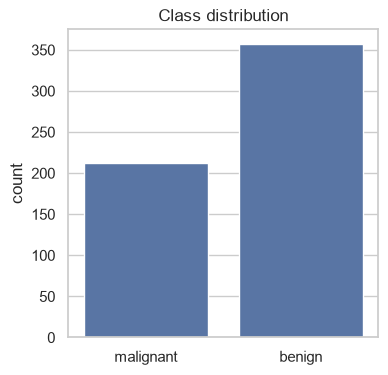

In [5]:
y = y_raw.map({"M": 1, "B": 0})

plt.figure(figsize=(4, 4))
sns.countplot(x=y_raw.map({"M": "malignant", "B": "benign"}))
plt.title("Class distribution")
plt.xlabel("")
plt.show()

Features also sit on very different scales — worst area runs into the thousands while smoothness stays below 1. SVM decision boundaries depend on distances between points, so unscaled features would let the large-magnitude columns dominate.

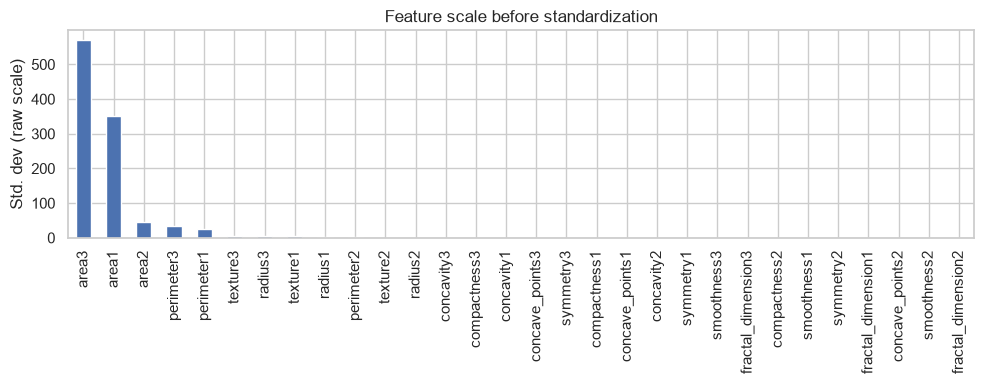

In [6]:
stds = X.std().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
stds.plot(kind="bar")
plt.ylabel("Std. dev (raw scale)")
plt.title("Feature scale before standardization")
plt.tight_layout()
plt.show()

### Split and scale

80:20 stratified split, then fit the scaler on the training set only so no test information leaks in.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, " Test:", X_test_s.shape)

Train:

 (455, 30)  Test: (114, 30)


### Baseline linear kernel

Train a linear-kernel SVM at default settings first, so there's something to compare the tuned model against.

In [8]:
svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train_s, y_train)
baseline_acc = accuracy_score(y_test, svm_linear.predict(X_test_s))
print(f"Baseline linear SVM test accuracy: {baseline_acc:.4f}")

Baseline linear SVM test accuracy: 0.9649


### Hyperparameter tuning

Grid search over C for the linear kernel, and, since kernel choice matters as much as C, include RBF and polynomial kernels in the same search. 5-fold cross-validation on the training set picks the winner.

In [9]:
param_grid = [
    {"kernel": ["linear"], "C": [0.01, 0.1, 1, 10, 100]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1]},
    {"kernel": ["poly"], "C": [0.1, 1, 10], "degree": [2, 3]},
]

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9758


The search picks an RBF kernel (C = 1, gamma = "scale") over the linear baseline, with a slightly higher cross-validation score. The decision boundary between malignant and benign cases isn't perfectly linear once all 30 features are in play, so the extra flexibility helps a little.

In [10]:
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_s)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))

Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1 score:  0.9630

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



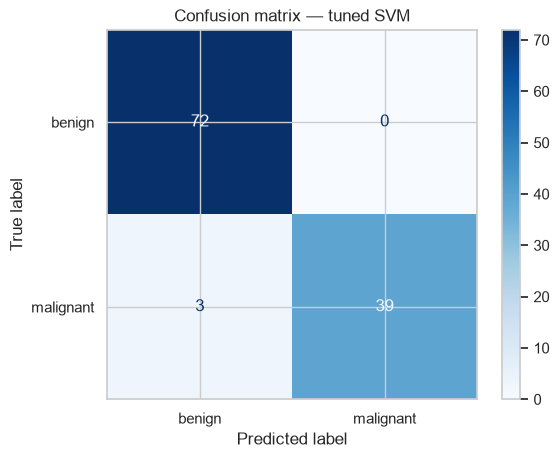

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"])
disp.plot(cmap="Blues")
plt.title("Confusion matrix — tuned SVM")
plt.show()

### Observations

- Tuning moved the winning model from a linear to an RBF kernel, a reminder that "explore hyperparameter tuning" should include kernel choice, not just C.
- Test accuracy reached 97.4%, but precision (1.00) and recall (0.93) tell different stories: every case the model flagged as malignant really was malignant, but it missed 3 of 42 actual malignant cases.
- Those 3 false negatives are the confusion matrix's only errors — 0 false positives. For a cancer screen, false negatives are the costlier mistake, so recall deserves more weight than accuracy alone when picking a final model.
- Scaling the features before fitting mattered as much as the kernel search, since SVM decision boundaries are built directly from feature distances.

## Part B — Principal Component Analysis

**Aim:** reduce the Wine dataset from 13 features to 2 principal components, check how much variance survives, and see what the components mean.

**Dataset:** UCI Wine, dataset id 109 — 178 samples, 13 numeric features, 3 cultivars.

### Load and standardize

The 13 features span very different ranges (proline runs into the hundreds, hue sits close to 1). PCA is a variance-based method, so without standardizing first, the high-variance columns alone would dominate the components.

In [12]:
wine = fetch_ucirepo(id=109)
wine_df = wine.data.features
wine_y = wine.data.targets["class"]

print(wine.metadata.name, "-", wine_df.shape[0], "samples,", wine_df.shape[1], "features")
print("Missing values:", wine_df.isna().sum().sum())
print("Class counts:\n", wine_y.value_counts())

X_wine_s = StandardScaler().fit_transform(wine_df)

Wine - 178 samples, 13 features
Missing values: 0
Class counts:
 class
2    71
1    59
3    48
Name: count, dtype: int64


### Reduce to 2 components

Fit PCA for 2 components and check how much of the original variance they capture.

In [13]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_wine_s)

for i, ratio in enumerate(pca2.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.4f}")
print(f"Total variance retained by 2 components: {pca2.explained_variance_ratio_.sum():.4f}")

PC1: 0.3620
PC2: 0.1921
Total variance retained by 2 components: 0.5541


### How many components for 95% variance?

Fit PCA with all 13 components to get the full variance curve, then find the smallest number of components whose cumulative variance clears 95%.

Cumulative variance: [0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202 0.9424 0.9617
 0.9791 0.992  1.    ]
Components needed for 95% variance: 10


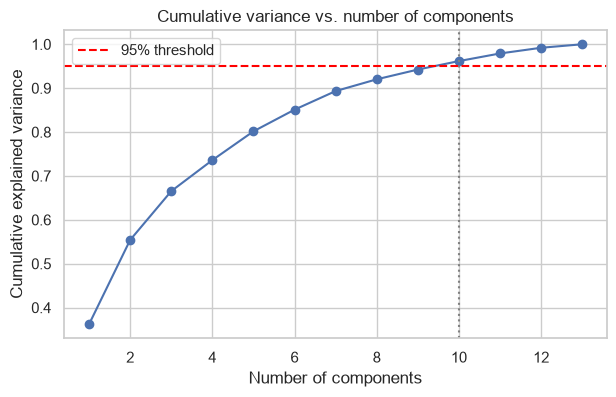

In [14]:
pca_full = PCA().fit(X_wine_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)
print("Cumulative variance:", np.round(cum_var, 4))
print(f"Components needed for 95% variance: {n_95}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 14), cum_var, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% threshold")
plt.axvline(n_95, color="grey", linestyle=":")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative variance vs. number of components")
plt.legend()
plt.show()

It takes 10 of the 13 components to reach 95% variance — the Wine dataset doesn't carry much redundant structure to compress. Two components keep only 55%, but that's still enough to see the three cultivars separate visually, as the next plot shows.

### Visualize the 2-component projection

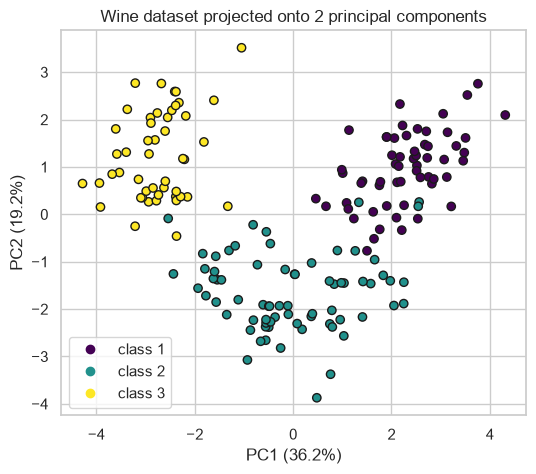

In [15]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=wine_y, cmap="viridis", edgecolor="k")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.title("Wine dataset projected onto 2 principal components")
plt.legend(handles=scatter.legend_elements()[0], labels=[f"class {c}" for c in sorted(wine_y.unique())])
plt.show()

### Original vs. transformed dataset

- **Number of features:** 13 raw measurements vs. 2 principal components.
- **Information retained:** the 2 components keep 55% of total variance; reaching 95% needs 10 components, so the 2D projection trades information for something you can actually plot.
- **Computational efficiency:** downstream models train on 2 numbers per sample instead of 13. For 178 rows the difference is negligible, but the saving scales with dataset size and feature count.

### What do PC1 and PC2 represent?

Check which original features load most heavily on each component.

In [16]:
loadings = pd.DataFrame(pca2.components_.T, index=wine_df.columns, columns=["PC1", "PC2"])
print("Top PC1 loadings:")
print(loadings["PC1"].reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(5))
print()
print("Top PC2 loadings:")
print(loadings["PC2"].reindex(loadings["PC2"].abs().sort_values(ascending=False).index).head(5))

Top PC1 loadings:
Flavanoids                      0.422934
Total_phenols                   0.394661
0D280_0D315_of_diluted_wines    0.376167
Proanthocyanins                 0.313429
Nonflavanoid_phenols           -0.298533
Name: PC1, dtype: float64

Top PC2 loadings:
Color_intensity    0.529996
Alcohol            0.483652
Proline            0.364903
Ash                0.316069
Magnesium          0.299634
Name: PC2, dtype: float64


PC1 is driven by flavanoids, total phenols and OD280/OD315 — the wine's phenolic-compound profile. PC2 is driven by color intensity, alcohol and proline — closer to the wine's body and strength. The two axes capture genuinely different chemical properties rather than just splitting noise.

### PCA — advantages, limitations, applications

- **Advantages:** removes correlated redundancy, makes high-dimensional data plottable, speeds up downstream models, and drops low-variance directions that are often just noise.
- **Limitations:** unsupervised — it maximizes variance, not class separability, so components can mix classes together; it's a linear method, so it misses non-linear structure; components are combinations of every original feature, which makes them harder to explain than the raw measurements.
- **Applications:** compressing image and sensor data, preprocessing before clustering or visualization, removing multicollinearity before regression, noise reduction.

## Extra credit — LDA vs. PCA

LDA is supervised: instead of maximizing variance, it maximizes separation between the known class labels. Fit it to 2 linear discriminants using the same class labels.

In [17]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_s, wine_y)
print("Explained variance ratio (LDA):", lda.explained_variance_ratio_)

Explained variance ratio (LDA): [0.68747889 0.31252111]


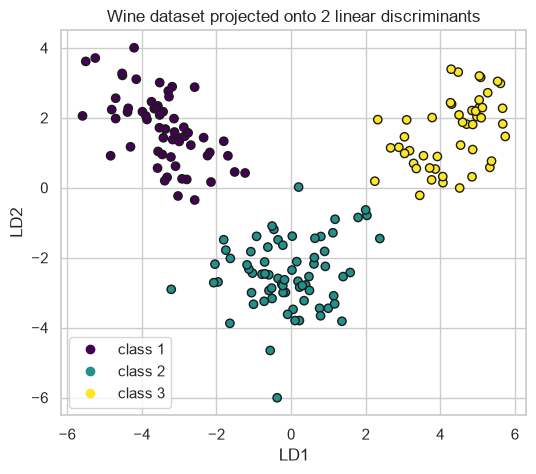

In [18]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=wine_y, cmap="viridis", edgecolor="k")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Wine dataset projected onto 2 linear discriminants")
plt.legend(handles=scatter.legend_elements()[0], labels=[f"class {c}" for c in sorted(wine_y.unique())])
plt.show()

LDA separates the three cultivars into distinct, almost non-overlapping clusters, while the PCA plot shows some overlap near the boundaries. That's expected: LDA is told the labels and optimizes directly for separability, while PCA never sees the labels at all. PCA is the right choice when there's no label or the goal is compression and general visualization; LDA is the right choice when labels exist and separation is the actual goal — though it caps the number of discriminants at (classes − 1), which is 2 here regardless of how many features exist.

## Inference

- The tuned SVM reached 97.4% test accuracy on the Wisconsin dataset, with perfect precision but recall of only 93% — 3 malignant cases slipped through as false negatives. Kernel search mattered here: RBF edged out the linear baseline once all 30 features were in play.
- PCA compressed the Wine dataset from 13 features to 2 while keeping 55% of the variance, and needed 10 components to keep 95%. Dimensionality reduction has a real information cost, and how steep that cost is depends on how correlated the original features are.
- LDA produced cleaner class separation than PCA on the same data because it uses the labels PCA ignores. That contrast is the core distinction between the two halves of this lab: PCA and LDA both reduce dimensions, but PCA compresses and visualizes structure without supervision, while LDA — like the SVM in Part A — is built to draw class boundaries using labels.